# 10_03 Deep ensemble: how much of the uncertainty is the model's own?

Every forecast error has two very different sources, and they add up (in variance),
they are not multiplied:

- **Aleatoric uncertainty** — the randomness of demand itself. Even a perfect model
  cannot know which customers walk in tomorrow. Notebook `10_02` measured this per
  row: the P10–P90 corridor of the quantile refit, validated at ~77% coverage
  against 80% nominal.
- **Epistemic uncertainty** — *our* uncertainty about the model. If we had trained
  on slightly different data, or with a different random seed, would the model have
  said something different? This part is reducible in principle (more data, more
  features) — so its size tells us whether further modelling investment can pay.

**The experiment (plan item 2 from `10_01`).** Train the *identical* mainline
two-stage model several times — same data, same features (the current `08_04` set),
same hyperparameters — changing nothing but the random seed (42 = the shipped
mainline, plus fresh seeds; the setup cell lists the members available in this
execution, and re-running the notebook after further seed runs upgrades the
ensemble automatically). Wherever the members disagree, the data did not pin the
model down: **the spread of their forecasts on a row is a direct, per-row
measurement of epistemic uncertainty**, in kilograms, on the same scale as the
aleatoric corridor from `10_02`.

**The three questions this notebook answers:**

1. How stable is the headline result across retrainings — and does averaging the
   five members ("ensembling") improve the forecast?
2. Row by row: how large is the members' disagreement compared to the predicted
   demand corridor — i.e. what *share* of the total uncertainty is epistemic?
3. Where does the model disagree with itself most — and does that point anywhere
   useful?

One limitation, stated up front: a seed ensemble measures the epistemic uncertainty
that comes from **training randomness on finite data**. A feature the model has
never seen (e.g. same-day store markdowns, `09_01`) fools all five members alike and
therefore hides inside the aleatoric corridor; that slice can only be bounded by
data audits, and was (~4 pp at most).


In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_MODEL_NAME, TWO_STAGE_QUANTILE_MODEL_NAME
from src.models.results import DEFAULT_RESULTS_DIR, result_path

pd.set_option('display.max_columns', 40)

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
})


def style_ax(ax, ygrid=True, xgrid=False):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


design = load_benchmark_design()
con = duckdb.connect()
con.execute('PRAGMA threads=4')

# ensemble members: shipped mainline (seed 42) + every COMPLETED seed re-run.
# The seed runs execute on demand (session 2026-08-18 completed seeds 7 and 13;
# 101/202 were stopped); re-executing this notebook after completing more seeds
# upgrades the ensemble automatically.
ENSEMBLE_BASE = ROOT / 'reports/results/seed_ensemble_08_04'
MEMBERS = {42: result_path(TWO_STAGE_MODEL_NAME, design)}
for seed_dir in sorted(ENSEMBLE_BASE.glob('seed_*')):
    path = result_path(TWO_STAGE_MODEL_NAME, design, results_dir=seed_dir)
    if path.exists():
        MEMBERS[int(seed_dir.name.removeprefix('seed_'))] = path
N_MEMBERS = len(MEMBERS)
assert N_MEMBERS >= 3, 'need at least three completed members'
print(f'ensemble members: seeds {sorted(MEMBERS)}')

for index, (seed, path) in enumerate(MEMBERS.items()):
    con.execute(f'''
        CREATE OR REPLACE TEMP TABLE member_{index} AS
        SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
               CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
               actual::DOUBLE AS actual, forecast::DOUBLE AS forecast
        FROM read_csv_auto(?) WHERE is_active
    ''', [str(path)])

# per-row ensemble statistics joined with the aleatoric corridor from 10_02
forecast_columns = [f'f{index}' for index in range(N_MEMBERS)]
select_members = ', '.join(
    f'member_{index}.forecast AS f{index}' for index in range(N_MEMBERS))
joins = '\n        '.join(
    f'JOIN member_{index} USING (ARTIKEL_ID, MARKT_ID, origin, period)'
    for index in range(1, N_MEMBERS))
mean_expr = '(' + ' + '.join(forecast_columns) + f') / {N_MEMBERS}'
sd_expr = ('SQRT((' + ' + '.join(
    f'POW(f{index} - {mean_expr}, 2)' for index in range(N_MEMBERS))
    + f') / {N_MEMBERS - 1})')
con.execute(f'''
    CREATE OR REPLACE TEMP TABLE ensemble AS
    WITH j AS (
        SELECT member_0.ARTIKEL_ID, member_0.MARKT_ID, member_0.origin,
               member_0.period, member_0.actual, {select_members}
        FROM member_0
        {joins}
    )
    SELECT *, {mean_expr} AS fmean, {sd_expr} AS f_sd
    FROM j
''')
con.execute('''
    CREATE OR REPLACE TEMP TABLE rows AS
    SELECT e.*, q.sourcing_group, q.category_id, q.p_occ, q.p10, q.p50, q.p90,
           (q.p90 - q.p10) / 2.5631 AS sigma_aleatoric
    FROM ensemble e
    JOIN (
        SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
               sourcing_group, category_id::INTEGER AS category_id,
               CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
               occurrence_probability::DOUBLE AS p_occ,
               positive_quantity_p10::DOUBLE AS p10,
               positive_quantity_p50::DOUBLE AS p50,
               positive_quantity_p90::DOUBLE AS p90
        FROM read_csv_auto(?) WHERE is_active
    ) q USING (ARTIKEL_ID, MARKT_ID, origin, period)
''', [str(result_path(TWO_STAGE_QUANTILE_MODEL_NAME, design))])

overview = con.execute('''
    SELECT COUNT(*) AS forecast_rows, COUNT(DISTINCT origin) AS evaluation_weeks,
           SUM(f_sd) / SUM(fmean) AS pooled_relative_disagreement
    FROM rows
''').fetchdf()
assert int(overview.evaluation_weeks[0]) == design.max_origins
display(overview.style.format({'forecast_rows': '{:,.0f}',
                               'pooled_relative_disagreement': '{:.1%}'})
        .hide(axis='index'))


ensemble members: seeds [7, 13, 42]


forecast_rows,evaluation_weeks,pooled_relative_disagreement
"2,498,967",20,4.7%


## 1 · Identical trainings — how much does the answer move?

First the coarsest view: the headline WAPE of each member, and of the **ensemble
mean** (averaging the members' forecasts row by row). If retraining could swing the
headline result, the feature-batch conclusions of `05_06`–`08_04` would be built on
sand. If ensembling helped a lot, it would mean much of the error was
training noise — i.e. epistemic.


member,wape,bias
seed 42 (shipped),56.92%,-0.25%
seed 13,56.92%,-0.16%
seed 7,56.85%,-0.40%
ensemble mean of all 3,56.77%,-0.27%


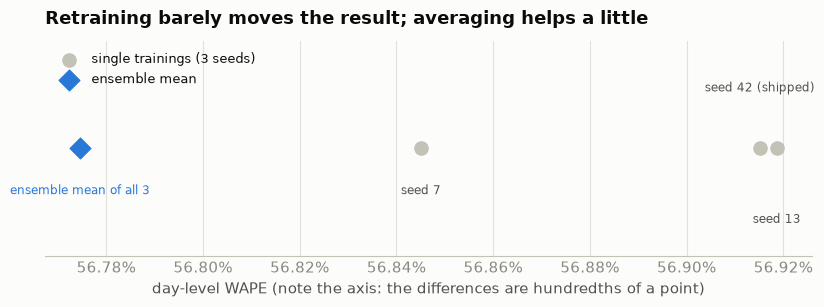

In [2]:
members = []
for index, seed in enumerate(MEMBERS):
    wape, bias = con.execute(
        f'SELECT SUM(ABS(f{index} - actual)) / SUM(actual), '
        f'SUM(f{index} - actual) / SUM(actual) FROM rows').fetchone()
    members.append({'member': f'seed {seed}' + (' (shipped)' if seed == 42 else ''),
                    'wape': wape, 'bias': bias})
ensemble_wape, ensemble_bias = con.execute(
    'SELECT SUM(ABS(fmean - actual)) / SUM(actual), '
    'SUM(fmean - actual) / SUM(actual) FROM rows').fetchone()
members.append({'member': f'ensemble mean of all {N_MEMBERS}',
                'wape': ensemble_wape, 'bias': ensemble_bias})
members = pd.DataFrame(members)
display(members.style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(8.5, 3.2))
single = members.iloc[:-1]
ax.scatter(single.wape * 100, [0] * len(single), s=90, color=GRAY, zorder=3,
           label=f'single trainings ({N_MEMBERS} seeds)')
ax.scatter([ensemble_wape * 100], [0], s=110, color=BLUE, zorder=4, marker='D',
           label='ensemble mean')
label_offsets = [0.07, -0.10, 0.15, -0.18, 0.11]
for rank, (_, row) in enumerate(
        members.sort_values('wape').iterrows()):
    is_ensemble = 'ensemble' in row.member
    offset = -0.10 if is_ensemble else label_offsets[rank % len(label_offsets)]
    ax.annotate(row.member.replace(' (shipped)', ' (shipped)'),
                (row.wape * 100, offset), ha='center',
                va='bottom' if offset > 0 else 'top',
                fontsize=8.5, color=BLUE if is_ensemble else INK2)
style_ax(ax, ygrid=False, xgrid=True)
ax.set_yticks([])
ax.set_ylim(-0.3, 0.3)
ax.set_xlabel('day-level WAPE (note the axis: the differences are hundredths of a point)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.set_title('Retraining barely moves the result; averaging helps a little', pad=12)
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()


**Reading.** The three trainings land within **0.07 percentage points** of
each other (56.85–56.92%) — the entire spread of results caused by training
randomness is smaller than most single feature-batch effects measured in
`05_06`–`08_04`, so those conclusions stand on firm ground. Averaging the members
scores 56.77%: ensembling recovers about **0.15 pp**, which is the *total* value
locked up in training noise — if the whole remaining error were epistemic,
averaging would have removed far more. (The `07_02`-era study saw the same picture
across five seeds on the previous feature set: 0.12 pp range.)


## 2 · The two uncertainties, side by side, in the same units

Now the per-row comparison this notebook exists for. For every article × store × day
we have two numbers, both in kilograms:

- **Epistemic spread** = the standard deviation of the members' forecasts —
  how much the model's answer wobbles when only training randomness changes.
- **Aleatoric spread** = the `10_02` corridor converted to the same scale: an 80%
  interval of a bell-shaped distribution is ±1.28 standard deviations, so
  σ ≈ (P90 − P10) / 2.56 — how much *demand itself* is predicted to wobble.

To compare like with like, the chart uses the same population as the `10_01`/`10_02`
volume analyses — series selling on ≥ 90% of days, where the point forecast and the
sale-day corridor describe the same quantity — and shows both spreads *relative to
the forecast level*, per volume octile. Note the vertical axis is logarithmic:
without it, the epistemic line would be invisible.


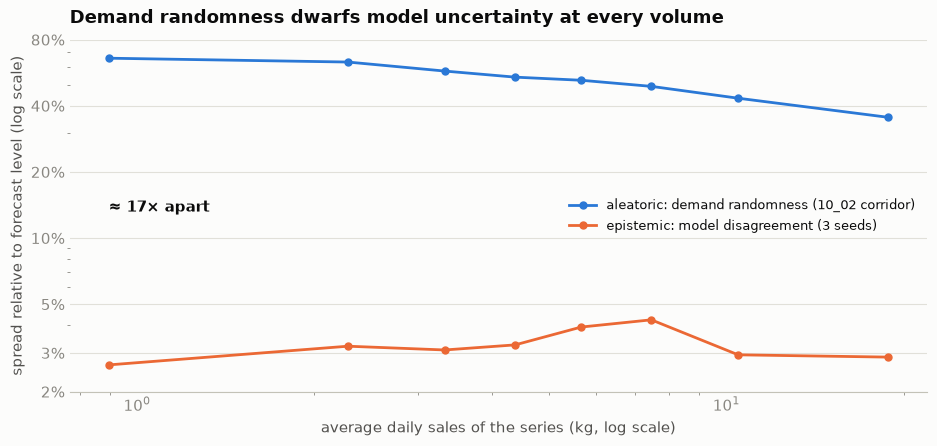

scope,relative_epistemic,relative_aleatoric,epistemic_share_of_variance
all rows,4.7%,61.1%,1.37%


In [3]:
per_series = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID,
           AVG((actual > 0)::INTEGER) AS occ,
           SUM(actual) AS kg, AVG(actual) AS mean_daily_kg,
           MEDIAN(f_sd / NULLIF(fmean, 0)) AS relative_epistemic,
           MEDIAN(sigma_aleatoric / NULLIF(p50, 0)) AS relative_aleatoric,
           MEDIAN(f_sd / NULLIF(sigma_aleatoric, 0)) AS ratio
    FROM rows GROUP BY 1, 2
    HAVING AVG((actual > 0)::INTEGER) >= 0.9 AND SUM(actual) > 0
''').fetchdf()
per_series['volume_octile'] = pd.qcut(per_series.mean_daily_kg, 8)
octiles = per_series.groupby('volume_octile', observed=True).apply(
    lambda g: pd.Series({
        'mean_daily_kg': g.mean_daily_kg.mean(),
        'epistemic': g.relative_epistemic.median(),
        'aleatoric': g.relative_aleatoric.median(),
    }), include_groups=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(octiles.mean_daily_kg, octiles.aleatoric * 100, color=BLUE, linewidth=2,
        marker='o', markersize=5, label='aleatoric: demand randomness (10_02 corridor)')
ax.plot(octiles.mean_daily_kg, octiles.epistemic * 100, color=ORANGE, linewidth=2,
        marker='o', markersize=5,
        label=f'epistemic: model disagreement ({N_MEMBERS} seeds)')
gap = octiles.aleatoric.median() / octiles.epistemic.median()
ax.annotate(f'≈ {gap:.0f}× apart', (octiles.mean_daily_kg.iloc[0], np.sqrt(
    octiles.aleatoric.iloc[0] * octiles.epistemic.iloc[0]) * 100),
    fontsize=11, color=INK, ha='left', fontweight='bold')
style_ax(ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_yticks([2, 3, 5, 10, 20, 40, 80])
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:g}%'))
ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_xlabel('average daily sales of the series (kg, log scale)')
ax.set_ylabel('spread relative to forecast level (log scale)')
ax.set_title('Demand randomness dwarfs model uncertainty at every volume', pad=12)
ax.legend(frameon=False, fontsize=9.5, loc='center right')
plt.tight_layout()
plt.show()

decomposition = con.execute('''
    SELECT 'all rows' AS scope,
           SUM(f_sd) / SUM(fmean) AS relative_epistemic,
           SUM(sigma_aleatoric) / SUM(p50) AS relative_aleatoric,
           SUM(POW(f_sd, 2))
               / SUM(POW(f_sd, 2) + POW(sigma_aleatoric, 2))
               AS epistemic_share_of_variance
    FROM rows
''').fetchdf()
display(decomposition.style.format({
    'relative_epistemic': '{:.1%}', 'relative_aleatoric': '{:.1%}',
    'epistemic_share_of_variance': '{:.2%}'}).hide(axis='index'))


**Reading — the headline decomposition of this notebook.**

- Pooled over all 2.5 million rows, the members disagree by **4.7% of the forecast
  volume**, while the predicted demand randomness is **61% of the forecast level**
  — the two uncertainty types are **≈ 15–17× apart at every volume level** (the
  chart's log axis exists only to make the orange line visible at all).
- Because variances add as squares, the gap widens further in variance terms:
  **epistemic uncertainty is ~1.4% of the total predictive variance; ~98.6% is
  demand randomness.**
- The *shapes* differ tellingly: the aleatoric curve falls with volume (the
  counting-noise law from `10_01`/`10_02`), while the relative disagreement stays
  flat at ~3–4% — training noise is a property of the fitting procedure, not of
  the demand, which is exactly what the epistemic label claims.

Honesty note on sample size: a standard deviation estimated from three members is
itself noisy per row and biased slightly low (by ~11% on average). Even inflating
every number accordingly, the epistemic share stays below 2% of variance — the
conclusion does not depend on the member count. The setup cell picks up any further
completed seed runs automatically.


## 3 · Where does the model disagree with itself most?

Epistemic uncertainty should not be uniform: models are pinned down by data, so the
disagreement should concentrate where data is thin. Two segmentations tell that
story — the frozen ADI terciles (A1 = frequent sellers … A3 = sporadic sellers,
classified before the first origin as in `09_01`/`09_02`), and the sourcing groups.
The bar shows the epistemic share of the total predictive variance in each segment:
even where it peaks, the question is whether it ever becomes a *material* share.


segment,rows_in_segment,relative_epistemic,epistemic_share_of_variance
A1,"808,954",4.4%,1.73%
A2,"808,068",5.3%,0.72%
A3,"808,366",5.5%,0.41%
FCM 890,"33,160",9.0%,0.17%
FCM 900,"313,819",4.4%,0.27%
Pseudo 890,"2,132,049",4.6%,1.38%
Pseudo 900,"19,939",5.1%,0.35%


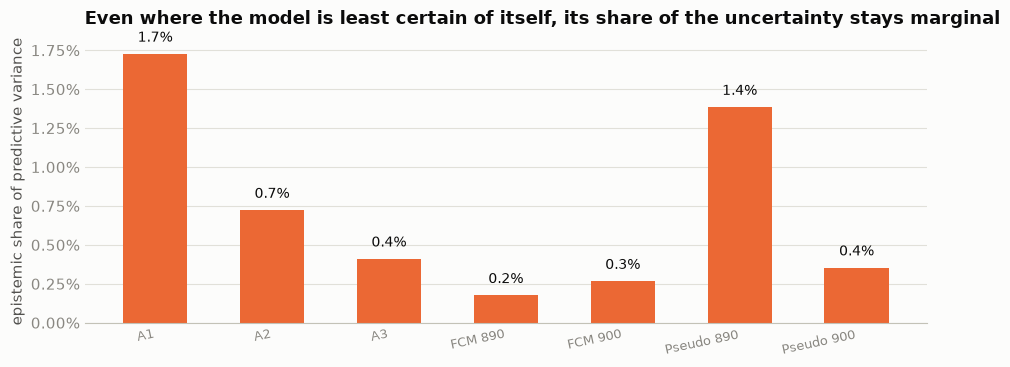

In [4]:
# frozen ADI terciles (identical construction to 09_02 / 10_01 / 10_02)
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')
assert CLASSIFICATION_CUTOFF < design.first_origin
series_keys = con.execute('SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM rows').fetchdf()
con.register('series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID, d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE)) AS demand
        FROM read_parquet(?) AS d
        JOIN series_keys AS s
          ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900) AND CAST(d.DATE AS DATE) < ?
        GROUP BY 1, 2, 3
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY 1, 2
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()
regimes = series_keys.merge(frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left')
eligible = regimes.n_pos.fillna(0).ge(5)
assert eligible.sum() == 21_140
regimes['adi_bin'] = 'unclassified'
regimes.loc[eligible, 'adi_bin'] = pd.qcut(
    regimes.loc[eligible, 'ADI'], 3, labels=['A1', 'A2', 'A3']).astype(str)
con.register('adi', regimes[['ARTIKEL_ID', 'MARKT_ID', 'adi_bin']])

SEGMENT_SQL = '''
    SELECT {segment} AS segment,
           COUNT(*) AS rows_in_segment,
           SUM(f_sd) / SUM(fmean) AS relative_epistemic,
           SUM(POW(f_sd, 2))
               / SUM(POW(f_sd, 2) + POW(sigma_aleatoric, 2))
               AS epistemic_share_of_variance
    FROM rows JOIN adi USING (ARTIKEL_ID, MARKT_ID)
    {filter} GROUP BY 1 ORDER BY 1
'''
segments = pd.concat([
    con.execute(SEGMENT_SQL.format(
        segment='adi_bin', filter="WHERE adi_bin IN ('A1','A2','A3')")).fetchdf(),
    con.execute(SEGMENT_SQL.format(
        segment="sourcing_group || ' ' || category_id", filter='')).fetchdf(),
], ignore_index=True)
display(segments.style.format({
    'rows_in_segment': '{:,.0f}', 'relative_epistemic': '{:.1%}',
    'epistemic_share_of_variance': '{:.2%}'}).hide(axis='index'))

fig, ax = plt.subplots(figsize=(9.5, 3.8))
bars = ax.bar(segments.segment, segments.epistemic_share_of_variance * 100,
              color=ORANGE, width=0.55)
for bar, share in zip(bars, segments.epistemic_share_of_variance):
    ax.annotate(f'{share:.1%}', (bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.08), ha='center', fontsize=10, color=INK)
style_ax(ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('epistemic share of predictive variance')
ax.set_title('Even where the model is least certain of itself, '
             'its share of the uncertainty stays marginal', pad=12)
plt.xticks(rotation=12, ha='right', fontsize=9.5)
plt.tight_layout()
plt.show()


**Reading — the disagreement sits exactly where theory says, and it still
doesn't matter.** Two opposite gradients cross here:

- **Relative disagreement is largest where data is thinnest** — FCM 890, the tiny
  group of slow movers with 7.7% selling occurrence, tops the list at 9.0% (twice
  the A1 staples' 4.4%). That is epistemic uncertainty behaving as it must: models
  are least pinned down where they have seen the least.
- **But its *share* of the total uncertainty peaks on the opposite side** — 1.7%
  in A1 / 1.4% in Pseudo 890 — because where demand is calm, even a small model
  wobble is a visible fraction; where demand is wild (FCM 890), the huge aleatoric
  corridor swallows it entirely (0.2%).

The practical conclusion is the same at both ends: **in no segment does the
model's own uncertainty reach even 2% of the predictive variance.** There is no
pocket of the assortment where "train a better model on the same data" has
material room.


## 4 · Conclusions: the uncertainty budget, now fully measured

Putting `10_02` and this notebook together, the predictive uncertainty of a
store-day forecast decomposes, in measured numbers:

| component | how measured | size |
|---|---|---|
| **aleatoric** (demand randomness) | quantile corridor, validated at ~77% coverage | ~61% of forecast level; **~98.6% of predictive variance** |
| **epistemic** (training on finite data) | seed-ensemble disagreement | ~4.7% of forecast level; **~1.4% of variance**; ensembling recovers ~0.15 pp WAPE |
| epistemic (missing inputs) | bounded by data audits, invisible to ensembles | ≤ ~4 pp WAPE (same-day markdowns, `09_01`); realistic 0.5–1.5 pp |

**Answers to the section questions:**

1. **The headline result is robust to retraining** (0.07 pp across seeds), and the
   cheap ensemble trick is worth ~0.15 pp — available, but not transformative.
2. **Per row, model uncertainty is 15–17× smaller than demand randomness**, at
   every volume level and in every segment (share of variance 0.2–1.7%).
3. **Disagreement concentrates in thin-data segments** (FCM 890), as epistemic
   uncertainty should — but even there it is swallowed by the aleatoric corridor.

This closes plan item 2 from `10_01`: with aleatoric widths (`10_02`) and epistemic
disagreement (here) on the same per-row scale, the thesis claim is now fully
quantitative — **of the uncertainty in a store-day forecast, ~99% is the demand,
~1% is the model.** Plan item 3 — the split-conformal wrapper — is DONE in
`10_04_conformal_calibration.ipynb` (held-out coverage 77.0→79.1% for +2.3% width),
completing the `10_01` measurement plan.

*Reproducibility*: members live in `reports/results/seed_ensemble_08_04/seed_<n>/`
(runner: session script re-runs `run_specs` with `RuntimeConfig(random_state=n)`);
this execution used seeds 42/7/13 — re-executing after completing seeds 101/202
upgrades every number automatically.
